<a href="https://colab.research.google.com/github/Mageed-Ghaleb/OptimizationSystems-Course/blob/main/Lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6 — Capstone Case Study: CP-SAT vs Metaheuristic on Sequencing with Setup Times (Colab-ready)

You are the operations analyst. A packaging line must process product orders on a single machine.
Switching product families incurs sequence-dependent setup time.

This lab follows an end-to-end workflow:
1) read the story and inspect inputs,
2) build a model (CP-SAT),
3) build a heuristic baseline (Simulated Annealing),
4) compare solutions and communicate the plan.

You can scale up by editing the Data cell (add jobs, change setup times).

## 0) Setup (Colab installs + imports)

In [1]:
!pip -q install ortools numpy pandas matplotlib

import numpy as np
import pandas as pd
import math, random, time
import matplotlib.pyplot as plt

from ortools.sat.python import cp_model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 20.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.5 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.5 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.5 which is incompatible.


## 1) Story and inputs

Story
- There are n jobs. Each job has processing time p[j] and due date d[j].
- If job i is immediately followed by job j, an additional setup time s[i,j] is required.
- The machine starts at time 0. All jobs must be processed exactly once. No preemption.
- Objective: minimize total tardiness plus a small penalty on total setup time.

Outputs
- A job sequence (permutation)
- Start and completion times, tardiness per job
- Total tardiness, total setup time, objective value

## 2) Data cell (edit here to scale up)

In [2]:
# Jobs table (edit to add jobs)
jobs_df = pd.DataFrame({
    "job": list(range(8)),
    "p":   [6, 3, 7, 4, 5, 2, 8, 3],
    "d":   [10, 8, 18, 12, 15, 7, 22, 14],
})

jobs_df

,job,p,d
0,0,6,10
1,1,3,8
2,2,7,18
3,3,4,12
4,4,5,15
5,5,2,7
6,6,8,22
7,7,3,14


In [3]:
# Setup time matrix s[i,j] (edit freely)
# Convention: s[i,i] = 0. We also use a dummy start node 'S' with index n.
n = len(jobs_df)
S = n

# Example job families (edit as you like)
family = {0:"A", 1:"A", 2:"B", 3:"B", 4:"C", 5:"A", 6:"C", 7:"B"}

def setup_time(i, j):
    if i == S:  # from start
        return 0
    if family[i] == family[j]:
        return 0
    # cross-family setup
    return 2 if (family[i], family[j]) in [("A","B"),("B","A")] else 3

s = {}
for i in range(n+1):
    for j in range(n):
        if i == j:
            s[(i,j)] = 0
        else:
            s[(i,j)] = setup_time(i, j)

setup_df = pd.DataFrame([[s[(i,j)] for j in range(n)] for i in range(n+1)],
                        index=[*range(n), "S"],
                        columns=[*range(n)])
setup_df

,0,1,2,3,4,5,6,7
0,0,0,2,2,3,0,3,2
1,0,0,2,2,3,0,3,2
2,2,2,0,0,3,2,3,0
3,2,2,0,0,3,2,3,0
4,3,3,3,3,0,3,0,3
5,0,0,2,2,3,0,3,2
6,3,3,3,3,0,3,0,3
7,2,2,0,0,3,2,3,0
S,0,0,0,0,0,0,0,0


## 3) Core utilities

In [4]:
p = jobs_df.set_index("job")["p"].to_dict()
d = jobs_df.set_index("job")["d"].to_dict()

def evaluate_sequence(seq, p, d, s, S):
    # Returns: (total_tardiness, total_setup, schedule_df)
    C = 0
    total_T = 0
    total_setup = 0
    rows = []
    prev = S
    for pos, j in enumerate(seq):
        st = s[(prev, j)]
        total_setup += st
        start = C + st
        C = start + p[j]
        T = max(0, C - d[j])
        total_T += T
        rows.append({"pos": pos, "job": j, "setup_from_prev": st, "start": start, "end": C, "d": d[j], "T": T})
        prev = j
    return total_T, total_setup, pd.DataFrame(rows)

def objective(seq, p, d, s, S, lam=0.2):
    TT, SU, _ = evaluate_sequence(seq, p, d, s, S)
    return TT + lam * SU

# Baseline start: Earliest Due Date
edd_seq = sorted(range(n), key=lambda j: d[j])
objective(edd_seq, p, d, s, S), edd_seq

(74.2, [5, 1, 0, 3, 7, 4, 2, 6])

In [5]:
# Inspect baseline schedule table
TT0, SU0, sched0 = evaluate_sequence(edd_seq, p, d, s, S)
TT0, SU0

(72, 11)

In [6]:
sched0

,pos,job,setup_from_prev,start,end,d,T
0,0,5,0,0,2,7,0
1,1,1,0,2,5,8,0
2,2,0,0,5,11,10,1
3,3,3,2,13,17,12,5
4,4,7,0,17,20,14,6
5,5,4,3,23,28,15,13
6,6,2,3,31,38,18,20
7,7,6,3,41,49,22,27


## 4) CP-SAT model (circuit + timing)

Modeling approach
- Create a directed arc variable x[i,j] meaning i immediately precedes j.
- Enforce one Hamiltonian tour that starts at a dummy node S and visits every job once.
- Add start/end time variables and implication constraints: if x[i,j]=1 then start[j] >= end[i] + s[i,j].
- Tardiness variables T[j] >= end[j] - d[j].
- Objective: minimize sum(T[j]) + lam * sum(setup[i,j] * x[i,j]).

In [7]:
def solve_cpsat(jobs_df, p, d, s, S, lam=0.2, time_limit_s=10.0):
    n = len(jobs_df)
    model = cp_model.CpModel()

    # Arc variables x[i,j] for i in jobs plus S, j in jobs (i != j)
    x = {}
    for i in range(n+1):
        for j in range(n):
            if i == j:
                continue
            x[(i,j)] = model.NewBoolVar(f"x_{i}_{j}")

    # To build a Hamiltonian cycle, include arcs from jobs to S (end) via y[i]
    y = {i: model.NewBoolVar(f"y_{i}_to_S") for i in range(n)}

    # In-degree: each job has exactly one predecessor (job or S)
    for j in range(n):
        model.Add(sum(x[(i,j)] for i in range(n+1) if i != j) == 1)

    # Out-degree: each job has exactly one successor (job or S)
    for i in range(n):
        model.Add(sum(x[(i,j)] for j in range(n) if j != i) + y[i] == 1)

    # S has exactly one outgoing arc (start to first job)
    model.Add(sum(x[(S,j)] for j in range(n)) == 1)

    # Exactly one job returns to S (choose end)
    model.Add(sum(y[i] for i in range(n)) == 1)

    # Circuit arcs list (nodes 0..n, where node n represents S)
    arcs = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            arcs.append([i, j, x[(i,j)]])
    for j in range(n):
        arcs.append([S, j, x[(S,j)]])
    for i in range(n):
        arcs.append([i, S, y[i]])

    model.AddCircuit(arcs)

    # Time horizon bound
    max_setup = max(s[(i,j)] for i in range(n+1) for j in range(n) if i != j)
    horizon = sum(p.values()) + n * max_setup + 5

    start = {j: model.NewIntVar(0, horizon, f"start_{j}") for j in range(n)}
    end = {j: model.NewIntVar(0, horizon, f"end_{j}") for j in range(n)}
    tard = {j: model.NewIntVar(0, horizon, f"T_{j}") for j in range(n)}

    for j in range(n):
        model.Add(end[j] == start[j] + p[j])
        model.Add(tard[j] >= end[j] - d[j])
        model.Add(tard[j] >= 0)

    # Implications for adjacency
    for i in range(n+1):
        for j in range(n):
            if i == j:
                continue
            if (i,j) in x:
                if i == S:
                    model.Add(start[j] >= s[(S,j)]).OnlyEnforceIf(x[(S,j)])
                else:
                    model.Add(start[j] >= end[i] + s[(i,j)]).OnlyEnforceIf(x[(i,j)])

    # Objective
    tard_sum = sum(tard[j] for j in range(n))
    setup_sum = sum(int(s[(i,j)]) * x[(i,j)] for (i,j) in x if i != j)
    # add lam via scaling to stay integer-ish
    lam_num = int(round(lam * 100))
    model.Minimize(tard_sum * 100 + lam_num * setup_sum)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = float(time_limit_s)
    solver.parameters.num_search_workers = 8

    status = solver.Solve(model)
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    # Recover successors
    succ = {}
    for (i,j), var in x.items():
        if solver.Value(var) == 1:
            succ[i] = j
    last = None
    for i, var in y.items():
        if solver.Value(var) == 1:
            last = i

    # Build sequence by following from S
    seq = []
    cur = S
    for _ in range(n):
        nxt = succ[cur]
        seq.append(nxt)
        cur = nxt
        if cur == last:
            break
    # Follow any remaining (safety)
    while len(seq) < n:
        cur = seq[-1]
        nxt = succ[cur]
        if nxt == S:
            break
        seq.append(nxt)

    rows = []
    prev = S
    for pos, j in enumerate(seq):
        rows.append({
            "pos": pos,
            "job": j,
            "setup_from_prev": s[(prev, j)],
            "start": solver.Value(start[j]),
            "end": solver.Value(end[j]),
            "d": d[j],
            "T": solver.Value(tard[j]),
        })
        prev = j

    schedule = pd.DataFrame(rows)
    total_T = int(schedule["T"].sum())
    total_setup = int(schedule["setup_from_prev"].sum())
    obj = (total_T * 100 + lam_num * total_setup) / 100.0

    return {
        "status": "OPTIMAL" if status == cp_model.OPTIMAL else "FEASIBLE",
        "seq": seq,
        "schedule": schedule,
        "total_tardiness": total_T,
        "total_setup": total_setup,
        "objective": obj,
        "solve_time_s": solver.WallTime(),
    }

In [8]:
cpsat_res = solve_cpsat(jobs_df, p, d, s, S, lam=0.2, time_limit_s=10.0)
cpsat_res["status"], cpsat_res["objective"], cpsat_res["seq"]

('OPTIMAL', 62.0, [1, 5, 0, 7, 3, 2, 4, 6])

In [9]:
cpsat_res["schedule"]

,pos,job,setup_from_prev,start,end,d,T
0,0,1,0,0,3,8,0
1,1,5,0,3,5,7,0
2,2,0,0,5,11,10,1
3,3,7,2,13,16,14,2
4,4,3,0,16,20,12,8
5,5,2,0,20,27,18,9
6,6,4,3,30,35,15,20
7,7,6,0,35,43,22,21


## 5) Metaheuristic baseline: Simulated Annealing (swap neighborhood)

In [10]:
def random_neighbor_swap(seq):
    n = len(seq)
    i, k = random.sample(range(n), 2)
    if i > k: i, k = k, i
    s2 = list(seq)
    s2[i], s2[k] = s2[k], s2[i]
    return s2

def simulated_annealing_seq(init_seq, p, d, s, S, lam=0.2, n_iters=8000, T0=60.0, alpha=0.998):
    curr = list(init_seq)
    curr_val = objective(curr, p, d, s, S, lam=lam)
    best = curr[:]
    best_val = curr_val
    T = float(T0)
    hist = [best_val]

    for _ in range(n_iters):
        neigh = random_neighbor_swap(curr)
        neigh_val = objective(neigh, p, d, s, S, lam=lam)
        delta = neigh_val - curr_val

        accept = (delta <= 0) or (random.random() < math.exp(-delta / max(T, 1e-12)))
        if accept:
            curr, curr_val = neigh, neigh_val
            if curr_val < best_val:
                best, best_val = curr[:], curr_val

        T *= alpha
        hist.append(best_val)

    return best, best_val, hist

In [11]:
sa_seq, sa_obj, sa_hist = simulated_annealing_seq(edd_seq, p, d, s, S, lam=0.2)
sa_obj, sa_seq

(62.0, [1, 5, 0, 7, 3, 2, 4, 6])

## 6) Compare CP-SAT vs SA

In [12]:
TT_sa, SU_sa, sched_sa = evaluate_sequence(sa_seq, p, d, s, S)
TT_cp, SU_cp, sched_cp = evaluate_sequence(cpsat_res["seq"], p, d, s, S)

summary = pd.DataFrame([
    {"method": "CP-SAT", "objective": cpsat_res["objective"], "total_tardiness": TT_cp, "total_setup": SU_cp, "time_s": cpsat_res["solve_time_s"]},
    {"method": "Simulated Annealing", "objective": sa_obj, "total_tardiness": TT_sa, "total_setup": SU_sa, "time_s": np.nan},
]).sort_values("objective")
summary

,method,objective,total_tardiness,total_setup,time_s
0,CP-SAT,62.0,61,5,3.628139
1,Simulated Annealing,62.0,61,5,NaN


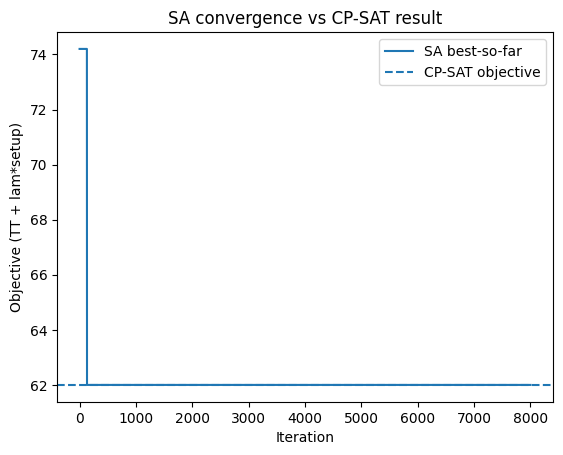

In [13]:
plt.figure()
plt.plot(sa_hist, label="SA best-so-far")
plt.axhline(cpsat_res["objective"], linestyle="--", label="CP-SAT objective")
plt.xlabel("Iteration")
plt.ylabel("Objective (TT + lam*setup)")
plt.legend()
plt.title("SA convergence vs CP-SAT result")
plt.show()

## 7) Deliverable schedule table (what you would send to operations)

In [14]:
best_method = "CP-SAT" if cpsat_res["objective"] <= sa_obj else "SA"
best_seq = cpsat_res["seq"] if best_method == "CP-SAT" else sa_seq

TT, SU, sched = evaluate_sequence(best_seq, p, d, s, S)

best_method, TT, SU

('CP-SAT', 61, 5)

In [15]:
sched

,pos,job,setup_from_prev,start,end,d,T
0,0,1,0,0,3,8,0
1,1,5,0,3,5,7,0
2,2,0,0,5,11,10,1
3,3,7,2,13,16,14,2
4,4,3,0,16,20,12,8
5,5,2,0,20,27,18,9
6,6,4,3,30,35,15,20
7,7,6,0,35,43,22,21


## 8) Exercises (students modify and re-run)

1) Add 2 new jobs to jobs_df. Re-run CP-SAT and SA. Which degrades more?
2) Increase cross-family setup times (edit setup_time). How does the sequence change?
3) Change lam. When does the solver sacrifice tardiness to reduce setups?
4) Try SA with an insert neighborhood as an extension.

# Case Study B — Logistics: VRPTW (2 vehicles) with OR-Tools
In this section we solve the **Vehicle Routing Problem with Time Windows (VRPTW)** that matches the logistics use case from Lecture 11.

We will:
1) define a toy instance (customers, depot, travel times, service times, time windows),
2) solve it with OR-Tools' routing solver,
3) extract a dispatch-ready route table (arrival/service/departure times),
4) compare against a simple greedy baseline (optional).

In [16]:
# Additional OR-Tools imports for VRPTW (Routing Solver)
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

## B1) VRPTW data (toy instance)

We use a depot (node 0) and a set of customer stops (nodes 1..m).

**Parameters**
- Travel time/cost \(c_{ij}\) derived from Euclidean distance on a grid (toy).
- Service time \(\tau_i\) (minutes).
- Time window \([a_i,b_i]\) for service start time.
- 2 vehicles starting/ending at depot.

You can edit the table below to add stops.

In [17]:
# Toy VRPTW instance (edit freely)
vrp_df = pd.DataFrame({
    "node": list(range(0, 11)),  # 0 is depot
    "x":    [50, 45, 55, 52, 48, 60, 42, 58, 47, 53, 62],
    "y":    [50, 52, 48, 60, 58, 55, 45, 42, 62, 40, 50],
    # service times (minutes); depot service time = 0
    "service": [0, 10, 10, 12, 8,  10, 9,  11, 7,  9,  10],
    # time windows [a,b] for service start (minutes from 0)
    "a": [0,  20,  0,  60, 30,  80, 10,  0,  50,  0,  70],
    "b": [300, 120, 100, 180, 160, 240, 140, 130, 220, 110, 260],
})
vrp_df

,node,x,y,service,a,b
0,0,50,50,0,0,300
1,1,45,52,10,20,120
2,2,55,48,10,0,100
3,3,52,60,12,60,180
4,4,48,58,8,30,160
5,5,60,55,10,80,240
6,6,42,45,9,10,140
7,7,58,42,11,0,130
8,8,47,62,7,50,220
9,9,53,40,9,0,110


In [18]:
# Build travel-time matrix c_ij (integer minutes) from Euclidean distance
coords = vrp_df.set_index("node")[["x","y"]].to_dict("index")
nodes = vrp_df["node"].tolist()
n_nodes = len(nodes)

def euclid_time(i, j, speed=1.0):
    xi, yi = coords[i]["x"], coords[i]["y"]
    xj, yj = coords[j]["x"], coords[j]["y"]
    dist = ((xi-xj)**2 + (yi-yj)**2)**0.5
    return int(round(dist / speed))

time_matrix = [[euclid_time(i, j) for j in nodes] for i in nodes]

# Quick peek
pd.DataFrame(time_matrix, index=nodes, columns=nodes).iloc[:5,:5]

,0,1,2,3,4
0,0,5,5,10,8
1,5,0,11,11,7
2,5,11,0,12,12
3,10,11,12,0,4
4,8,7,12,4,0


## B2) Solve VRPTW using OR-Tools Routing

We model:
- 2 vehicles start/end at depot 0,
- time dimension accumulates travel time + service time,
- time window constraints on each node.

In [19]:
def solve_vrptw_ortools(vrp_df, time_matrix, num_vehicles=2, depot=0, time_limit_s=10):
    nodes = vrp_df["node"].tolist()
    idx_of = {node:i for i, node in enumerate(nodes)}
    n = len(nodes)

    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, idx_of[depot])
    routing = pywrapcp.RoutingModel(manager)

    # Transit callback: travel time between nodes
    def transit_cb(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        i = nodes[from_node]
        j = nodes[to_node]
        return time_matrix[idx_of[i]][idx_of[j]]

    transit_callback_index = routing.RegisterTransitCallback(transit_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Time dimension (travel + service)
    service = vrp_df.set_index("node")["service"].to_dict()
    def time_cb(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        i = nodes[from_node]
        j = nodes[to_node]
        return time_matrix[idx_of[i]][idx_of[j]] + service[i]

    time_callback_index = routing.RegisterTransitCallback(time_cb)

    horizon = int(vrp_df["b"].max() + 200)
    routing.AddDimension(
        time_callback_index,
        30,      # waiting slack allowed
        horizon, # maximum time
        False,   # don't force start cumul to zero (we will set depot window)
        "Time"
    )
    time_dim = routing.GetDimensionOrDie("Time")

    # Time windows
    for node in nodes:
        a = int(vrp_df.loc[vrp_df["node"]==node, "a"].iloc[0])
        b = int(vrp_df.loc[vrp_df["node"]==node, "b"].iloc[0])
        index = manager.NodeToIndex(idx_of[node])
        time_dim.CumulVar(index).SetRange(a, b)

    # Make depot window wide
    depot_index = manager.NodeToIndex(idx_of[depot])
    time_dim.CumulVar(depot_index).SetRange(int(vrp_df.loc[vrp_df["node"]==depot,"a"].iloc[0]),
                                            int(vrp_df.loc[vrp_df["node"]==depot,"b"].iloc[0]))

    # Search parameters
    params = pywrapcp.DefaultRoutingSearchParameters()
    params.time_limit.FromSeconds(int(time_limit_s))
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH

    solution = routing.SolveWithParameters(params)
    if solution is None:
        return None

    # Extract routes and a route table with times
    routes = []
    rows = []
    for v in range(num_vehicles):
        index = routing.Start(v)
        prev_node = None
        seq = []
        while not routing.IsEnd(index):
            node_id = nodes[manager.IndexToNode(index)]
            seq.append(node_id)
            t = solution.Value(time_dim.CumulVar(index))
            rows.append({
                "vehicle": v,
                "node": node_id,
                "arrival_or_service_start": t,
            })
            prev_node = node_id
            index = solution.Value(routing.NextVar(index))
        # add end depot
        node_id = nodes[manager.IndexToNode(index)]
        t = solution.Value(time_dim.CumulVar(index))
        rows.append({"vehicle": v, "node": node_id, "arrival_or_service_start": t})
        seq.append(node_id)
        routes.append(seq)

    route_table = pd.DataFrame(rows)

    # Compute total travel cost from objective
    total_cost = solution.ObjectiveValue()

    return {"routes": routes, "route_table": route_table, "objective": total_cost}

vrp_res = solve_vrptw_ortools(vrp_df, time_matrix, num_vehicles=2, depot=0, time_limit_s=10)
vrp_res["objective"], vrp_res["routes"]

(78, [[0, 0], [0, 1, 6, 9, 7, 2, 10, 5, 3, 4, 8, 0]])

In [20]:
vrp_res["route_table"]

,vehicle,node,arrival_or_service_start
0,0,0,0
1,0,0,0
2,1,0,0
3,1,1,20
4,1,6,38
5,1,9,59
6,1,7,73
7,1,2,91
8,1,10,108
9,1,5,123


## B3) Dispatch-ready route schedule table

We expand the route table to include:
- travel time from previous stop,
- service time,
- departure time,
- time window status.

In [21]:
def build_dispatch_table(vrp_df, time_matrix, routes, depot=0):
    idx_of = {node:i for i, node in enumerate(vrp_df["node"].tolist())}
    service = vrp_df.set_index("node")["service"].to_dict()
    tw = vrp_df.set_index("node")[["a","b"]].to_dict("index")

    out_rows = []
    for v, seq in enumerate(routes):
        # seq includes depot start and depot end
        t = 0
        prev = seq[0]
        # For depot, service=0
        for k in range(1, len(seq)):
            j = seq[k]
            travel = time_matrix[idx_of[prev]][idx_of[j]]
            arrive = t + travel
            start = max(arrive, tw[j]["a"])
            late = max(0, start - tw[j]["b"])
            depart = start + service[j]
            out_rows.append({
                "vehicle": v,
                "step": k-1,
                "from": prev,
                "to": j,
                "travel": travel,
                "arrive": arrive,
                "service_start": start,
                "service": service[j],
                "depart": depart,
                "TW_a": tw[j]["a"],
                "TW_b": tw[j]["b"],
                "late": late
            })
            t = depart
            prev = j
    return pd.DataFrame(out_rows)

dispatch_df = build_dispatch_table(vrp_df, time_matrix, vrp_res["routes"], depot=0)
dispatch_df

,vehicle,step,from,to,travel,arrive,service_start,service,depart,TW_a,TW_b,late
0,0,0,0,0,0,0,0,0,0,0,300,0
1,1,0,0,1,5,5,20,10,30,20,120,0
2,1,1,1,6,8,38,38,9,47,10,140,0
3,1,2,6,9,12,59,59,9,68,0,110,0
4,1,3,9,7,5,73,73,11,84,0,130,0
5,1,4,7,2,7,91,91,10,101,0,100,0
6,1,5,2,10,7,108,108,10,118,70,260,0
7,1,6,10,5,5,123,123,10,133,80,240,0
8,1,7,5,3,9,142,142,12,154,60,180,0
9,1,8,3,4,4,158,158,8,166,30,160,0


## B4) Simple greedy baseline (optional)

This baseline is **not guaranteed feasible** for time windows, but is useful for comparison and for showing why we need a solver.
We build a naive plan:
- assign stops alternately to vehicles in increasing \(b_i\) (earliest deadline),
- visit assigned stops in that same order.

Then we compute total travel time and lateness.

In [22]:
def greedy_vrptw_baseline(vrp_df, time_matrix, num_vehicles=2, depot=0):
    customers = [n for n in vrp_df["node"].tolist() if n != depot]
    # sort by latest allowed time b_i
    customers_sorted = sorted(customers, key=lambda i: int(vrp_df.loc[vrp_df["node"]==i,"b"].iloc[0]))
    # split
    buckets = [[] for _ in range(num_vehicles)]
    for idx, c in enumerate(customers_sorted):
        buckets[idx % num_vehicles].append(c)
    routes = []
    for v in range(num_vehicles):
        routes.append([depot] + buckets[v] + [depot])
    return routes

greedy_routes = greedy_vrptw_baseline(vrp_df, time_matrix, num_vehicles=2, depot=0)
greedy_dispatch = build_dispatch_table(vrp_df, time_matrix, greedy_routes, depot=0)

greedy_total_travel = int(greedy_dispatch["travel"].sum())
greedy_total_late = float(greedy_dispatch["late"].sum())

greedy_routes, greedy_total_travel, greedy_total_late

([[0, 2, 1, 6, 3, 5, 0], [0, 9, 7, 4, 8, 10, 0]], 131, 0.0)

## B5) Compare solver vs greedy baseline (toy KPIs)

KPIs shown:
- total travel time
- total lateness (if any)
- (optionally) number of late visits

In [23]:
solver_total_travel = int(dispatch_df["travel"].sum())
solver_total_late = float(dispatch_df["late"].sum())
solver_late_visits = int((dispatch_df["late"] > 0).sum())

baseline_late_visits = int((greedy_dispatch["late"] > 0).sum())

pd.DataFrame([
    {"method": "OR-Tools VRPTW (Routing + GLS)", "total_travel": solver_total_travel, "total_lateness": solver_total_late, "late_visits": solver_late_visits, "objective_reported_by_solver": vrp_res["objective"]},
    {"method": "Greedy baseline", "total_travel": greedy_total_travel, "total_lateness": greedy_total_late, "late_visits": baseline_late_visits, "objective_reported_by_solver": np.nan},
])

,method,total_travel,total_lateness,late_visits,objective_reported_by_solver
0,OR-Tools VRPTW (Routing + GLS),78,0.0,0,78.0
1,Greedy baseline,131,0.0,0,NaN


# Wrap-up: Two use cases solved in one lab

**Case A (Scheduling):** CP-SAT + SA baseline on single-machine sequencing with sequence-dependent setups.  
**Case B (Logistics VRPTW):** OR-Tools VRPTW solver + greedy baseline.

If you want a unified "Capstone" comparison slide/table, you can export:
- Case A schedule table + objective breakdown,
- Case B dispatch table + KPI breakdown.